# 🌽 Limpieza y Análisis de Producción de Maíz — SIAP

**Proyecto:** Pipeline ETL Agrícola — Análisis técnico-económico de cultivos en México  
**Fuente de datos:** SIAP / SADER — Avance de Siembras y Cosechas  
**Cultivo:** Maíz  
**Semestre:** 3er semestre — Licenciatura en Ciencias de Datos para Negocios  

---

## ¿Qué hace este notebook?

1. Lee el archivo `.xls` descargado del portal SIAP
2. Lo limpia paso a paso
3. Agrega columnas de contexto y columnas calculadas
4. Hace un análisis exploratorio básico
5. Guarda el resultado como CSV limpio

> **Nota técnica:** Los archivos del SIAP tienen extensión `.xls` pero en realidad son HTML disfrazado.
> Por eso usamos `BeautifulSoup` para leerlos en lugar de `openpyxl`.

## 1. Importar librerías

In [1]:
# Librerías que usaremos
# pandas  → manipulación de datos en tablas (DataFrames)
# BeautifulSoup → leer HTML (necesario porque el .xls del SIAP es HTML disfrazado)
# re      → expresiones regulares (para extraer el año del texto)
# os      → manejo de rutas y carpetas
# matplotlib → visualizaciones básicas

import pandas as pd
from bs4 import BeautifulSoup
import re
import os
import matplotlib.pyplot as plt

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Leer el archivo XLS del SIAP

El archivo descargado del portal es HTML con extensión `.xls`.  
Si intentamos abrirlo con `pd.read_excel()` dará error.  
La solución es leerlo como texto HTML con `BeautifulSoup`.

In [2]:
# Ruta del archivo descargado del SIAP
ARCHIVO = r'C:\Users\USER\Documents\Ciencia de datos\PP\src\Avance de Siembras y Cosechas.xls'

# Leer el archivo como texto
# El SIAP puede usar UTF-8 o latin-1 dependiendo del año
# Intentamos UTF-8 primero y si falla usamos latin-1
try:
    with open(ARCHIVO, 'r', encoding='utf-8') as f:
        contenido = f.read()
    print('✅ Archivo leído con encoding UTF-8')
except UnicodeDecodeError:
    with open(ARCHIVO, 'r', encoding='latin-1') as f:
        contenido = f.read()
    print('✅ Archivo leído con encoding latin-1')

print(f'Tamaño del archivo: {len(contenido):,} caracteres')

✅ Archivo leído con encoding UTF-8
Tamaño del archivo: 16,336 caracteres


## 3. Recuperar columnas ocultas

El portal del SIAP tiene la columna **Valor de Producción** comentada en el HTML:  
```html
<!--td>66,822.60</td-->
```
Esto significa que el dato existe pero está invisible en la página web.  
Lo recuperamos con un simple reemplazo de texto antes de parsear.

In [3]:
# Descomentar columnas ocultas
# El SIAP comenta el valor de producción así: <!--td>valor</td-->
# Lo convertimos en HTML normal para que BeautifulSoup lo pueda leer
contenido = contenido.replace('<!--td', '<td').replace('</td-->', '</td>')
contenido = contenido.replace('<!--th', '<th').replace('</th-->', '</th>')

print('✅ Columnas ocultas recuperadas')

✅ Columnas ocultas recuperadas


## 4. Parsear el HTML y encontrar las tablas

In [4]:
# Parsear el HTML con BeautifulSoup
soup = BeautifulSoup(contenido, 'lxml')

# Buscar todas las tablas en el archivo
tablas = soup.find_all('table')
print(f'Tablas encontradas: {len(tablas)}')

# Mostrar el año de cada tabla
# Cada tabla tiene un párrafo <p> antes que indica el año agrícola
for i, tabla in enumerate(tablas):
    parrafo = tabla.find_previous('p')
    texto = parrafo.get_text(strip=True) if parrafo else 'sin texto'
    print(f'  Tabla {i+1}: {texto[:60]}')

Tablas encontradas: 2
  Tabla 1: Año agrícola:2026Producción AgrícolaCiclo:Ciclicos - Perenne
  Tabla 2: Año agrícola:2025Producción AgrícolaCiclo:Ciclicos - Perenne


## 5. Extraer los datos de las tablas

El archivo tiene **2 tablas**:
- **Tabla 1:** Avance del año en curso (2026) — datos incompletos
- **Tabla 2:** Cierre del año anterior (2025) — datos completos ✅

Extraemos las dos y las etiquetamos con su año.

In [5]:
# Catálogo oficial de los 32 estados de México
# Lo usamos para filtrar solo filas válidas
# y descartar la fila de totales y cualquier basura
ESTADOS = {
    'Aguascalientes', 'Baja California', 'Baja California Sur',
    'Campeche', 'Coahuila', 'Colima', 'Chiapas', 'Chihuahua',
    'Ciudad de México', 'Durango', 'Guanajuato', 'Guerrero',
    'Hidalgo', 'Jalisco', 'México', 'Michoacán', 'Morelos',
    'Nayarit', 'Nuevo León', 'Oaxaca', 'Puebla', 'Querétaro',
    'Quintana Roo', 'San Luis Potosí', 'Sinaloa', 'Sonora',
    'Tabasco', 'Tamaulipas', 'Tlaxcala', 'Veracruz',
    'Yucatán', 'Zacatecas'
}

def limpiar_numero(valor):
    """
    Convierte un número con comas a float.
    Ejemplo: '1,465,056.72' → 1465056.72
    Retorna None si el valor no es convertible.
    """
    if valor is None or str(valor).strip() == '':
        return None
    try:
        return float(str(valor).replace(',', '').strip())
    except ValueError:
        return None

def extraer_anio(tabla):
    """
    Extrae el año agrícola del párrafo anterior a la tabla.
    Usa una expresión regular para encontrar el primer número de 4 dígitos.
    """
    parrafo = tabla.find_previous('p')
    texto = parrafo.get_text() if parrafo else ''
    resultado = re.search(r'(\d{4})', texto)
    return int(resultado.group(1)) if resultado else 0

def parsear_tabla(tabla, anio):
    """
    Lee una tabla HTML del SIAP y la convierte en una lista de diccionarios.
    Salta las primeras 2 filas (son encabezados) y filtra solo estados válidos.
    """
    filas = []
    for tr in tabla.find_all('tr')[2:]:   # las primeras 2 filas son encabezados
        celdas = tr.find_all(['td', 'th'])
        if len(celdas) < 5:
            continue
        estado = celdas[1].get_text(strip=True)
        if estado not in ESTADOS:         # descartar totales y basura
            continue
        filas.append({
            'anio'                       : anio,
            'cultivo'                    : 'Maíz',
            'ciclo'                      : 'Cíclicos - Perennes',
            'modalidad'                  : 'Riego + Temporal',
            'estado'                     : estado,
            'sup_sembrada_ha'            : limpiar_numero(celdas[2].get_text(strip=True)),
            'sup_cosechada_ha'           : limpiar_numero(celdas[3].get_text(strip=True)),
            'sup_siniestrada_ha'         : limpiar_numero(celdas[4].get_text(strip=True)),
            'valor_produccion_miles_mxn' : limpiar_numero(celdas[5].get_text(strip=True)) if len(celdas) > 5 else None
        })
    return pd.DataFrame(filas)

# Extraer las dos tablas
dataframes = []
for tabla in tablas:
    anio = extraer_anio(tabla)
    df   = parsear_tabla(tabla, anio)
    dataframes.append(df)
    print(f'✅ Año {anio}: {len(df)} estados extraídos')

✅ Año 2026: 32 estados extraídos
✅ Año 2025: 32 estados extraídos


## 6. Consolidar y revisar los datos

In [6]:
# Unir las dos tablas en un solo DataFrame
df = pd.concat(dataframes, ignore_index=True)

print(f'Total de registros: {len(df)}')
print(f'Años en el dataset: {sorted(df["anio"].unique())}')
print(f'Estados: {df["estado"].nunique()}')
print()
print('--- Primeras 5 filas ---')
df.head()

Total de registros: 64
Años en el dataset: [np.int64(2025), np.int64(2026)]
Estados: 32

--- Primeras 5 filas ---


,anio,cultivo,ciclo,modalidad,estado,sup_sembrada_ha,sup_cosechada_ha,sup_siniestrada_ha,valor_produccion_miles_mxn
0,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Aguascalientes,10917.17,4035.00,0.0,66822.60
1,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Baja California,83745.00,27307.16,0.0,554384.01
2,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Baja California Sur,10551.03,3580.66,0.0,163844.72
3,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Campeche,44186.51,2614.14,0.0,91705.03
4,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Coahuila,28640.50,17341.00,0.0,308774.84


In [7]:
# Revisar tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   anio                        64 non-null     int64  
 1   cultivo                     64 non-null     object 
 2   ciclo                       64 non-null     object 
 3   modalidad                   64 non-null     object 
 4   estado                      64 non-null     object 
 5   sup_sembrada_ha             64 non-null     float64
 6   sup_cosechada_ha            64 non-null     float64
 7   sup_siniestrada_ha          64 non-null     float64
 8   valor_produccion_miles_mxn  64 non-null     float64
dtypes: float64(4), int64(1), object(4)
memory usage: 4.6+ KB


## 7. Agregar columnas calculadas

Aquí es donde conectamos con las UCAs del semestre:

| Columna | Fórmula | UCA relacionada |
|---------|---------|----------------|
| `eficiencia` | cosechada / sembrada | Cálculo Integral |
| `perdida_ha` | sembrada − cosechada | Contabilidad |
| `pct_perdida` | pérdida / sembrada | Probabilidad |

In [8]:
# Eficiencia productiva
# Qué porcentaje de lo sembrado se logró cosechar
# 1.0 = todo lo sembrado se cosechó (ideal)
# 0.5 = solo la mitad se cosechó (pérdida del 50%)
df['eficiencia'] = (df['sup_cosechada_ha'] / df['sup_sembrada_ha']).round(4)

# Pérdida en hectáreas
# Cuántas hectáreas se sembraron pero no se cosecharon
df['perdida_ha'] = (df['sup_sembrada_ha'] - df['sup_cosechada_ha']).round(2)

# Porcentaje de pérdida
# Útil para comparar estados de diferente tamaño
df['pct_perdida'] = (df['perdida_ha'] / df['sup_sembrada_ha'] * 100).round(2)

print('✅ Columnas calculadas agregadas')
df[['estado', 'anio', 'eficiencia', 'perdida_ha', 'pct_perdida']].head(10)

✅ Columnas calculadas agregadas


,estado,anio,eficiencia,perdida_ha,pct_perdida
0,Aguascalientes,2026,0.3696,6882.17,63.04
1,Baja California,2026,0.3261,56437.84,67.39
2,Baja California Sur,2026,0.3394,6970.37,66.06
3,Campeche,2026,0.0592,41572.37,94.08
4,Coahuila,2026,0.6055,11299.50,39.45
5,Colima,2026,0.2099,18148.25,79.01
6,Chiapas,2026,0.5449,203694.59,45.51
7,Chihuahua,2026,0.7925,21614.66,20.75
8,Ciudad de México,2026,0.0412,172.00,95.88
9,Durango,2026,0.6931,12165.54,30.69


## 8. Separar los años

Para el análisis principal trabajamos con **2025** (datos de cierre completos).  
Los datos de 2026 son avance parcial — se pueden usar para comparación.

In [9]:
# Separar por año usando filtros, no por posición (más robusto)
df_2025 = df[df['anio'] == 2025].reset_index(drop=True)
df_2026 = df[df['anio'] == 2026].reset_index(drop=True)

print(f'Registros 2025: {len(df_2025)}')
print(f'Registros 2026: {len(df_2026)}')
print()
df_2025.head()

Registros 2025: 32
Registros 2026: 32



,anio,cultivo,ciclo,modalidad,estado,sup_sembrada_ha,sup_cosechada_ha,sup_siniestrada_ha,valor_produccion_miles_mxn,eficiencia,perdida_ha,pct_perdida
0,2025,Maíz,Cíclicos - Perennes,Riego + Temporal,Aguascalientes,117695.79,117448.54,0.0,5157654.84,0.9979,247.25,0.21
1,2025,Maíz,Cíclicos - Perennes,Riego + Temporal,Baja California,111516.12,106254.30,3964.5,15138709.71,0.9528,5261.82,4.72
2,2025,Maíz,Cíclicos - Perennes,Riego + Temporal,Baja California Sur,33827.69,32833.39,88.2,6311009.69,0.9706,994.30,2.94
3,2025,Maíz,Cíclicos - Perennes,Riego + Temporal,Campeche,289791.50,209265.10,0.0,4610341.43,0.7221,80526.40,27.79
4,2025,Maíz,Cíclicos - Perennes,Riego + Temporal,Coahuila,134544.41,127387.93,2566.0,7526022.94,0.9468,7156.48,5.32


## 9. Análisis exploratorio — Maíz 2025

### 9.1 Estadísticas generales

In [10]:
# Estadísticas básicas de las columnas numéricas
df_2025[['sup_sembrada_ha', 'sup_cosechada_ha', 'eficiencia', 'pct_perdida']].describe().round(2)

,sup_sembrada_ha,sup_cosechada_ha,eficiencia,pct_perdida
count,32.00,32.00,32.00,32.00
mean,518298.23,444614.20,0.86,14.10
std,423591.71,371552.07,0.12,12.22
min,13487.91,11146.10,0.44,0.21
25%,117036.34,105379.66,0.80,5.68
50%,386146.75,283659.30,0.89,11.40
75%,839240.36,751601.26,0.94,19.70
max,1465056.72,1297716.09,1.00,55.92


### 9.2 ¿Qué estados siembran más maíz?

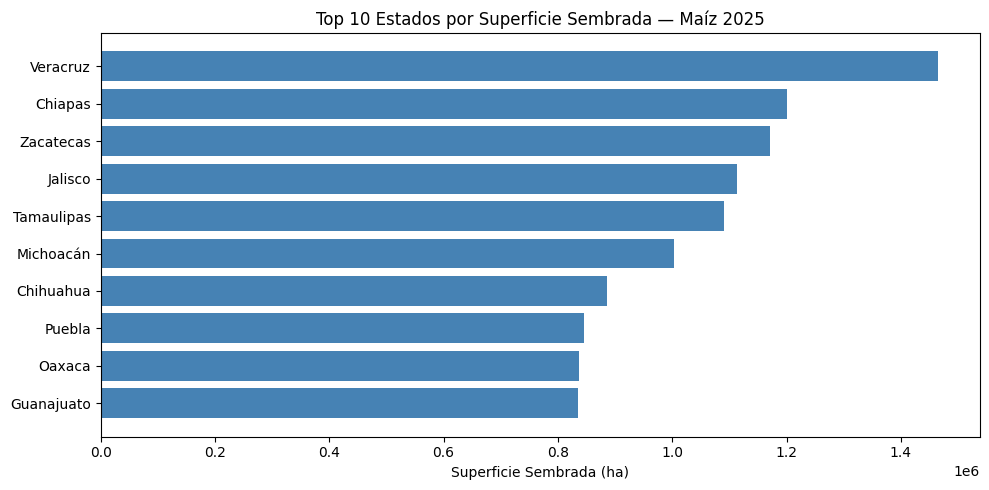

    estado  sup_sembrada_ha
  Veracruz       1465056.72
   Chiapas       1200742.41
 Zacatecas       1171387.01
   Jalisco       1112640.98
Tamaulipas       1089895.56
 Michoacán       1002417.86
 Chihuahua        886272.23
    Puebla        845309.01
    Oaxaca        837217.47
Guanajuato        835581.42


In [11]:
top_produccion = df_2025.sort_values('sup_sembrada_ha', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_produccion['estado'], top_produccion['sup_sembrada_ha'], color='steelblue')
plt.xlabel('Superficie Sembrada (ha)')
plt.title('Top 10 Estados por Superficie Sembrada — Maíz 2025')
plt.gca().invert_yaxis()  # el mayor queda arriba
plt.tight_layout()
plt.show()

print(top_produccion[['estado', 'sup_sembrada_ha']].to_string(index=False))

### 9.3 ¿Qué estados son más eficientes?

> **Hallazgo esperado:** Los estados que más siembran no siempre son los más eficientes.  
> Esto es relevante para el Problema Prototípico: un productor con poca tierra  
> puede ser más rentable si elige un cultivo eficiente en lugar de uno de alto volumen.

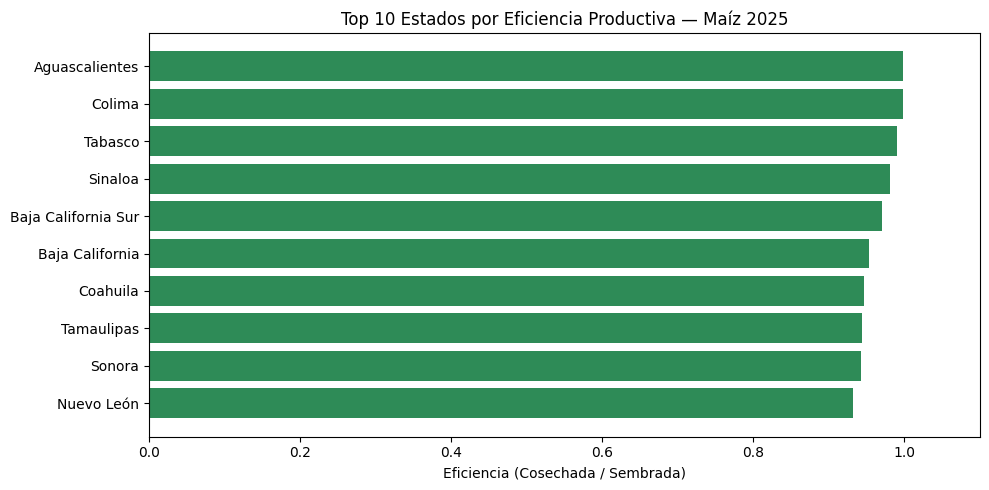

             estado  eficiencia
     Aguascalientes      0.9979
             Colima      0.9977
            Tabasco      0.9902
            Sinaloa      0.9813
Baja California Sur      0.9706
    Baja California      0.9528
           Coahuila      0.9468
         Tamaulipas      0.9443
             Sonora      0.9429
         Nuevo León      0.9320


In [12]:
top_eficiencia = df_2025.sort_values('eficiencia', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_eficiencia['estado'], top_eficiencia['eficiencia'], color='seagreen')
plt.xlabel('Eficiencia (Cosechada / Sembrada)')
plt.title('Top 10 Estados por Eficiencia Productiva — Maíz 2025')
plt.xlim(0, 1.1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_eficiencia[['estado', 'eficiencia']].to_string(index=False))

### 9.4 ¿Dónde se pierde más superficie?

> Esta sección conecta con la **UCA de Probabilidad**:  
> el porcentaje de pérdida histórico de un estado puede usarse para estimar  
> la probabilidad de siniestro en una temporada futura.

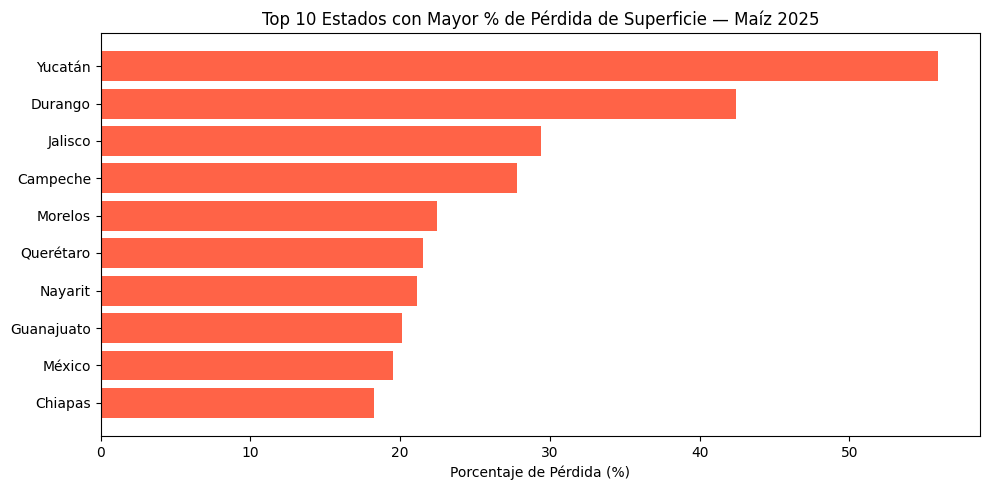

    estado  pct_perdida
   Yucatán        55.92
   Durango        42.41
   Jalisco        29.42
  Campeche        27.79
   Morelos        22.45
 Querétaro        21.51
   Nayarit        21.14
Guanajuato        20.15
    México        19.55
   Chiapas        18.23


In [13]:
top_perdida = df_2025.sort_values('pct_perdida', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_perdida['estado'], top_perdida['pct_perdida'], color='tomato')
plt.xlabel('Porcentaje de Pérdida (%)')
plt.title('Top 10 Estados con Mayor % de Pérdida de Superficie — Maíz 2025')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_perdida[['estado', 'pct_perdida']].to_string(index=False))

### 9.5 Producción vs Eficiencia — gráfico de dispersión

> Este gráfico muestra los **dos tipos de estados** que existen:  
> - **Tipo 1 — Alto volumen:** siembran mucho pero no siempre cosechan eficientemente  
> - **Tipo 2 — Alta eficiencia:** aprovechan mejor cada hectárea sembrada  
>
> Para el PP esto es clave: un productor periurbano con tierra limitada  
> debería aspirar a cultivos del cuadrante superior izquierdo (alta eficiencia, menor área).

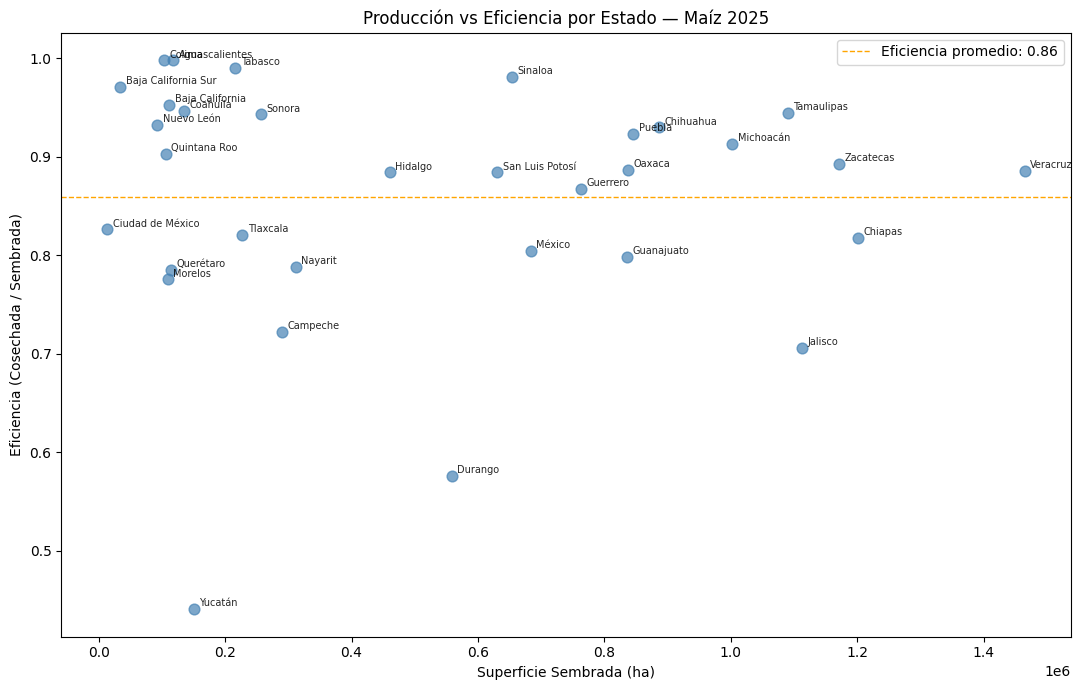

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(df_2025['sup_sembrada_ha'], df_2025['eficiencia'],
           color='steelblue', alpha=0.7, s=60)

# Etiquetar cada estado
for _, fila in df_2025.iterrows():
    ax.annotate(
        fila['estado'],
        (fila['sup_sembrada_ha'], fila['eficiencia']),
        fontsize=7, alpha=0.85,
        xytext=(4, 2), textcoords='offset points'
    )

# Línea de referencia: eficiencia promedio
promedio = df_2025['eficiencia'].mean()
ax.axhline(promedio, color='orange', linestyle='--', linewidth=1,
           label=f'Eficiencia promedio: {promedio:.2f}')

ax.set_xlabel('Superficie Sembrada (ha)')
ax.set_ylabel('Eficiencia (Cosechada / Sembrada)')
ax.set_title('Producción vs Eficiencia por Estado — Maíz 2025')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Guardar el CSV limpio

In [16]:
# Guardar dataset completo (2025 + 2026)
os.makedirs('data/processed', exist_ok=True)

df.to_csv('data/processed/maiz_produccion_siap.csv', index=False, encoding='utf-8-sig')


print('✅ Archivo guardado: data/processed/maiz_produccion_siap.csv')
print(f'   Registros totales : {len(df)}')
print(f'   Columnas          : {list(df.columns)}')
print()
print('--- Vista final ---')
df.head()

✅ Archivo guardado: data/processed/maiz_produccion_siap.csv
   Registros totales : 64
   Columnas          : ['anio', 'cultivo', 'ciclo', 'modalidad', 'estado', 'sup_sembrada_ha', 'sup_cosechada_ha', 'sup_siniestrada_ha', 'valor_produccion_miles_mxn', 'eficiencia', 'perdida_ha', 'pct_perdida']

--- Vista final ---


,anio,cultivo,ciclo,modalidad,estado,sup_sembrada_ha,sup_cosechada_ha,sup_siniestrada_ha,valor_produccion_miles_mxn,eficiencia,perdida_ha,pct_perdida
0,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Aguascalientes,10917.17,4035.00,0.0,66822.60,0.3696,6882.17,63.04
1,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Baja California,83745.00,27307.16,0.0,554384.01,0.3261,56437.84,67.39
2,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Baja California Sur,10551.03,3580.66,0.0,163844.72,0.3394,6970.37,66.06
3,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Campeche,44186.51,2614.14,0.0,91705.03,0.0592,41572.37,94.08
4,2026,Maíz,Cíclicos - Perennes,Riego + Temporal,Coahuila,28640.50,17341.00,0.0,308774.84,0.6055,11299.50,39.45


---

## Resumen de decisiones técnicas

| Decisión | Por qué |
|----------|--------|
| Usar `BeautifulSoup` en lugar de `pd.read_excel` | El archivo es HTML, no Excel real |
| Descomentar `<!--td-->` antes de parsear | El valor de producción estaba oculto en el HTML |
| Filtrar con catálogo de estados | Más robusto que filtrar por posición de fila |
| Separar años con filtro `df[df['anio'] == 2025]` | Más seguro que `iloc` que se rompe si cambia el formato |
| Guardar con `encoding='utf-8'` | Evita el carácter BOM invisible al inicio del archivo |

## Conexión con las UCAs del semestre

| Columna generada | UCA |
|-----------------|-----|
| `eficiencia` | Cálculo Integral — modelar rendimiento productivo |
| `perdida_ha` | Contabilidad Financiera — costo de superficie perdida |
| `pct_perdida` | Probabilidad — base para estimar riesgo de siniestro |
| `valor_produccion_miles_mxn` | Contabilidad Financiera — análisis de rentabilidad |